# Step 1: Performing EDA and cleaning 

In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Read data
df = pd.read_csv("brca_metabric_clinical_data.tsv", sep='\t')
df.columns = df.columns.str.replace(" ", "_") # Remove space from coloumn names
df = df.rename(columns={'Pam50_+_Claudin-low_subtype': 'Pam50_Claudin_low_subtype'}) # Rename coloumn as it contain +
# Checking percentage of missing data in each coloumn 
missing_per = df.isnull().mean()*100
print(missing_per[missing_per > 0].sort_values(ascending=False))
#print(df)

3-Gene_classifier_subtype         29.693105
Tumor_Stage                       28.736548
Primary_Tumor_Laterality          25.468314
Cellularity                       23.595058
Type_of_Breast_Surgery            22.080510
Integrative_Cluster               21.084097
Hormone_Therapy                   21.084097
Radio_Therapy                     21.084097
PR_Status                         21.084097
Inferred_Menopausal_State         21.084097
Patient's_Vital_Status            21.084097
Pam50_Claudin_low_subtype         21.084097
HER2_status_measured_by_SNP6      21.084097
Chemotherapy                      21.084097
HER2_Status                       21.084097
Overall_Survival_Status           21.044241
Overall_Survival_(Months)         21.044241
Lymph_nodes_examined_positive     10.601833
Nottingham_prognostic_index        8.848147
Mutation_Count                     6.018334
Tumor_Size                         5.938621
Tumor_Other_Histologic_Subtype     5.380630
Relapse_Free_Status_(Months)    

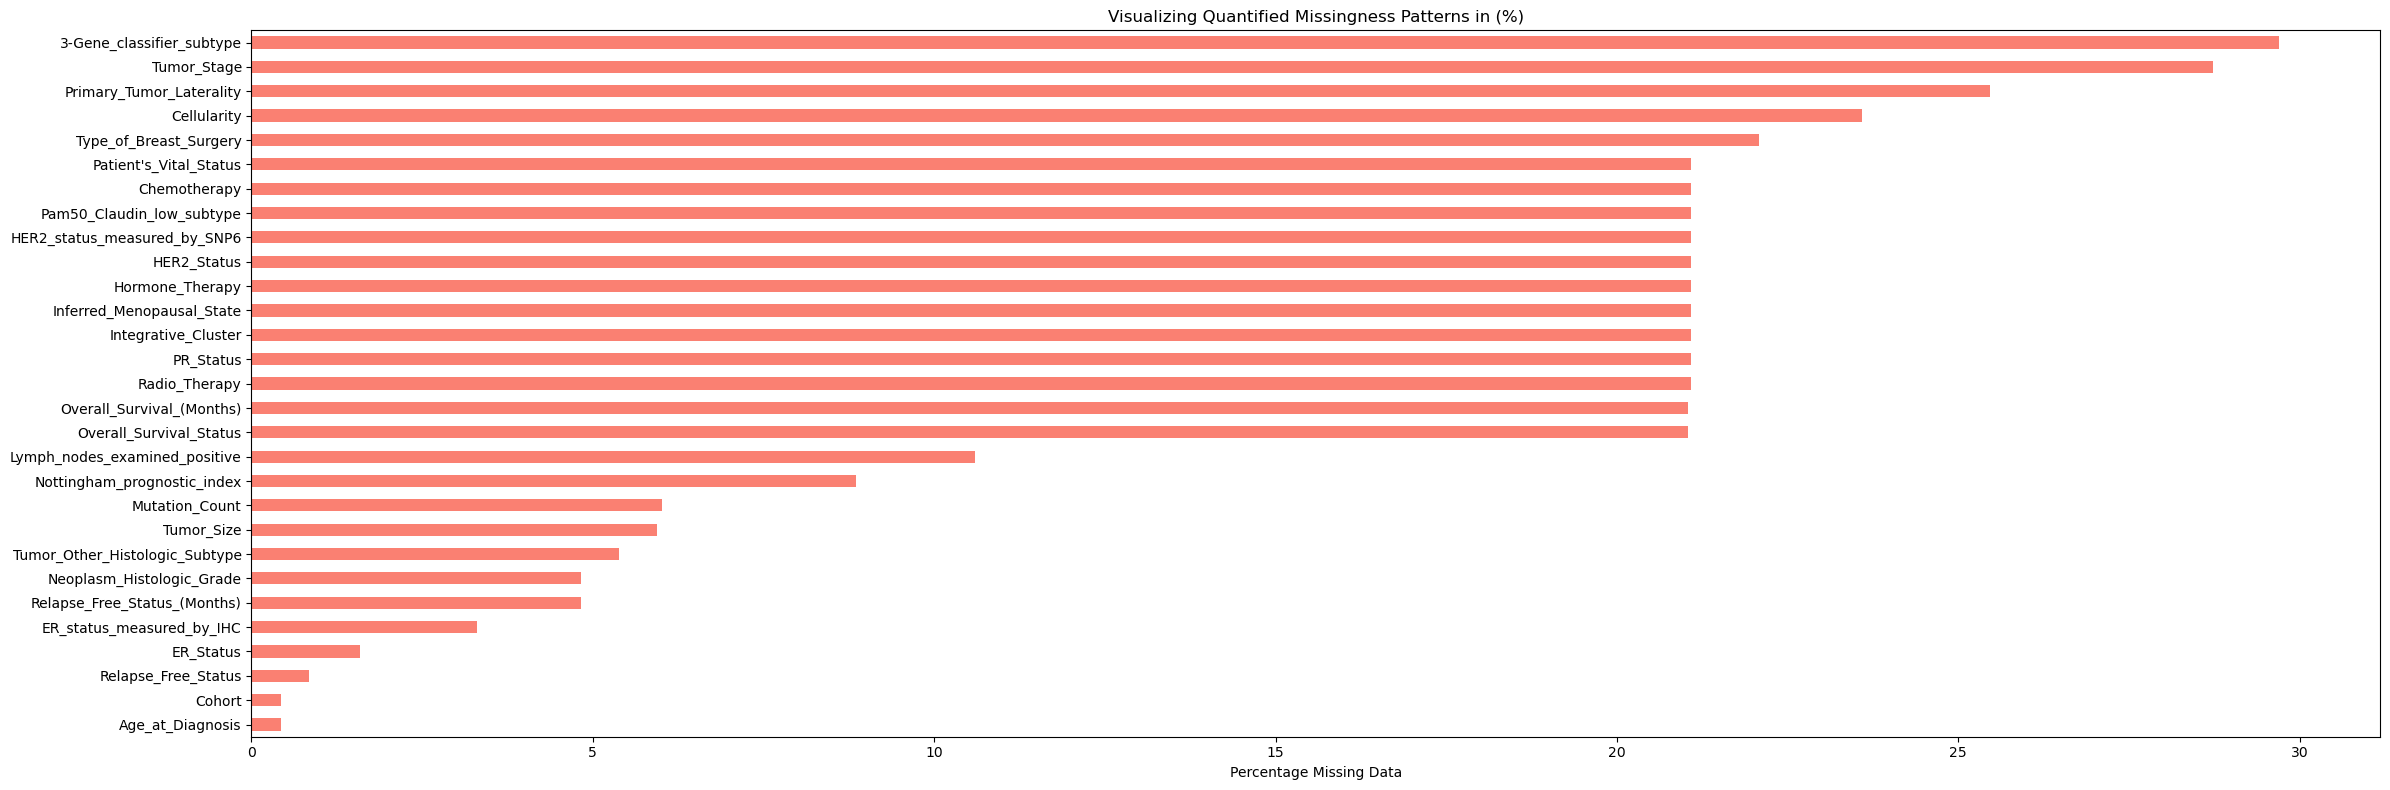

In [16]:
# Visualization of missingness distribution
plt.figure(figsize=(24, 8))
missing_per[missing_per > 0].sort_values().plot(kind='barh', color='salmon')
plt.title("Visualizing Quantified Missingness Patterns in (%)")
plt.xlabel("Percentage Missing Data")
plt.tight_layout()
plt.show()

--- Age_at_Diagnosis Stats ---
IQR: 19.08 | Lower Outlier Threshold: 22.30 | Upper Outlier Threshold: 98.62

--- Cohort Stats ---
IQR: 3.00 | Lower Outlier Threshold: -3.50 | Upper Outlier Threshold: 8.50

--- Neoplasm_Histologic_Grade Stats ---
IQR: 1.00 | Lower Outlier Threshold: 0.50 | Upper Outlier Threshold: 4.50

--- Lymph_nodes_examined_positive Stats ---
IQR: 2.00 | Lower Outlier Threshold: -3.00 | Upper Outlier Threshold: 5.00

--- Mutation_Count Stats ---
IQR: 4.00 | Lower Outlier Threshold: -3.00 | Upper Outlier Threshold: 13.00

--- Nottingham_prognostic_index Stats ---
IQR: 1.99 | Lower Outlier Threshold: 0.06 | Upper Outlier Threshold: 8.03

--- Overall_Survival_(Months) Stats ---
IQR: 124.27 | Lower Outlier Threshold: -125.53 | Upper Outlier Threshold: 371.53

--- Relapse_Free_Status_(Months) Stats ---
IQR: 128.77 | Lower Outlier Threshold: -152.06 | Upper Outlier Threshold: 363.04

--- TMB_(nonsynonymous) Stats ---
IQR: 5.23 | Lower Outlier Threshold: -3.92 | Upper Outl

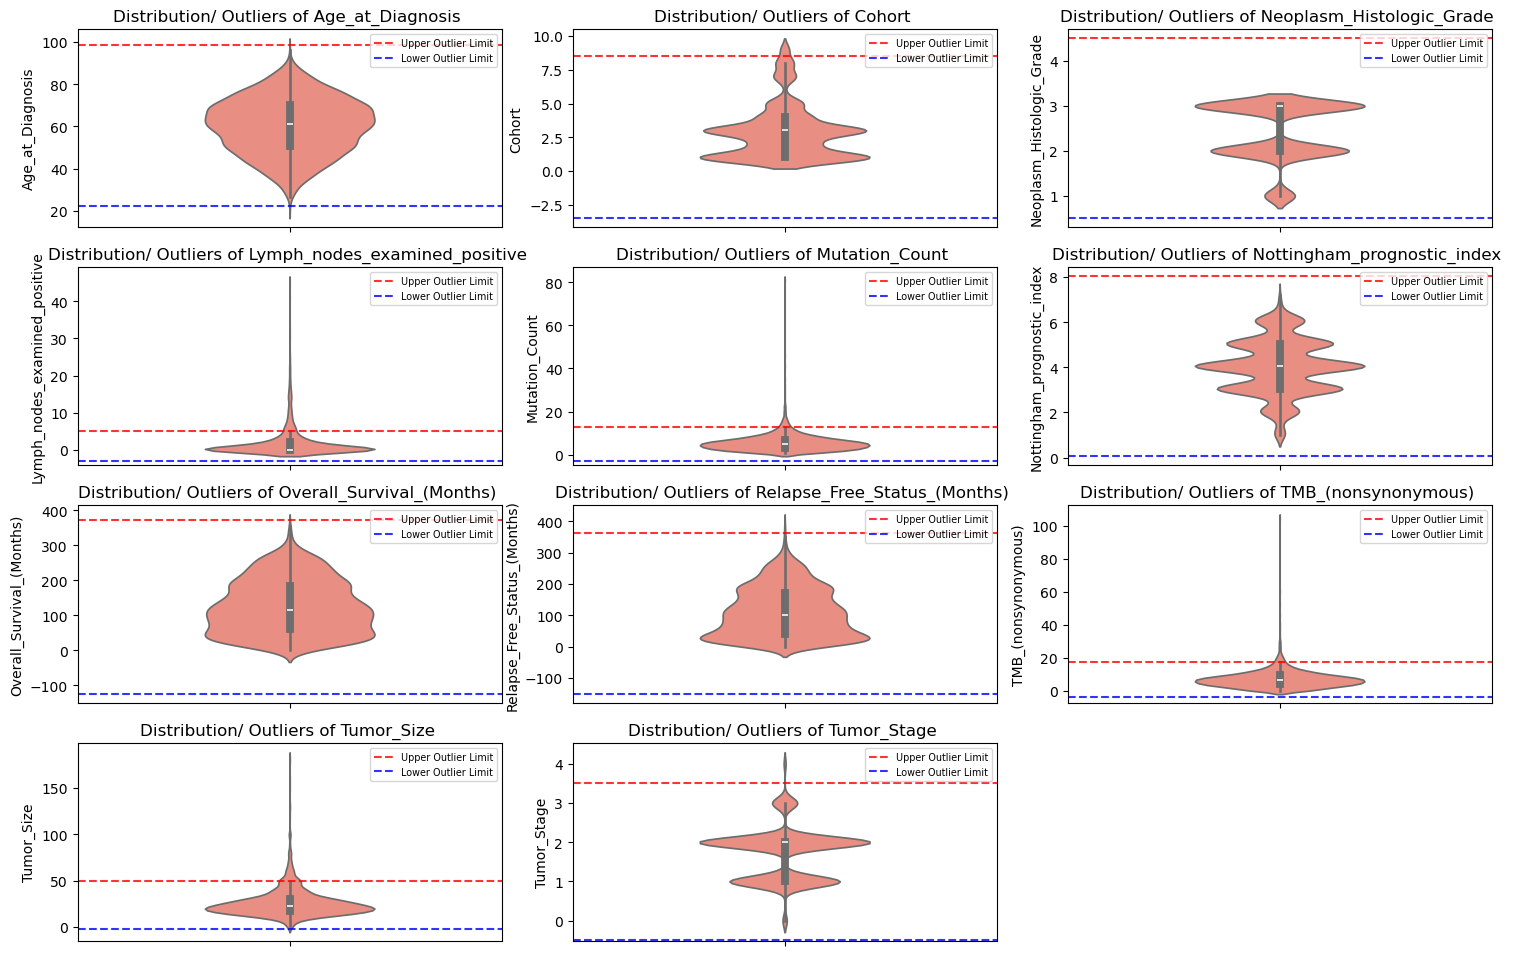

In [100]:
# Making violin plot to check for distribution and outliers in numerical features
#num_features = ['Age_at_Diagnosis', 'Lymph_nodes_examined_positive', 'Mutation_Count', 'Nottingham_prognostic_index', 
#                'Overall_Survival_(Months)', 'Relapse_Free_Status_(Months)', 'TMB_(nonsynonymous)', 'Tumor_Size', 'Cohort', 'Tumor_Stage'] 

num_features = df.select_dtypes(include=['float64']).columns
plt.figure(figsize= (15, 12))
for i, col in enumerate(num_features,1):
    plt.subplot(5, 3, i)

    # Calculating IQR for outliers 
    clean_series = df[col].dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    print(f"--- {col} Stats ---")
    print(f"IQR: {iqr:.2f} | Lower Outlier Threshold: {lower_bound:.2f} | Upper Outlier Threshold: {upper_bound:.2f}\n")
    
    
    sns.violinplot(y = df[col], color='salmon', width = 0.4)
    plt.axhline(upper_bound, color='red', linestyle='--', alpha=0.8, label='Upper Outlier Limit')
    plt.axhline(lower_bound, color='blue', linestyle='--', alpha=0.8, label='Lower Outlier Limit')
    plt.title(f'Distribution/ Outliers of {col} ')
    plt.legend(loc='upper right', fontsize='x-small')    
plt.tight_layout()
plt.show()
 

In [101]:
# Data cleaning based on distrbution we have above and using some domain knowledge
cols_to_drop = ["Study_ID", "Patient_ID", "Sample_ID", "Cancer_Type", "Overall_Survival_(Months)",
                 "Number_of_Samples_Per_Patient", "Sample_Type", "Sex", "Patient's_Vital_Status"
                 ] # here wwe are using columns that does not contribute towards our aim or giving the same info as any other column

df_clean = df.drop(columns= cols_to_drop)
df_clean = df_clean.dropna(subset = ['Overall_Survival_Status'])
#df_clean.shape
categorical_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[categorical_cols] = df_clean[categorical_cols].fillna('Unknown') # replacing NaN values with 'Unknown' this is needed for RF

df_clean.to_csv("Clean_Metadata_BRCA.csv", index=False) # Save clean data
#print(f"Data shape after initial structural clean: {df_clean.shape}")


/var/folders/nw/2dm_8qhd5rj3vc08k7bw9ss80000gn/T/ipykernel_29728/2219421815.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns


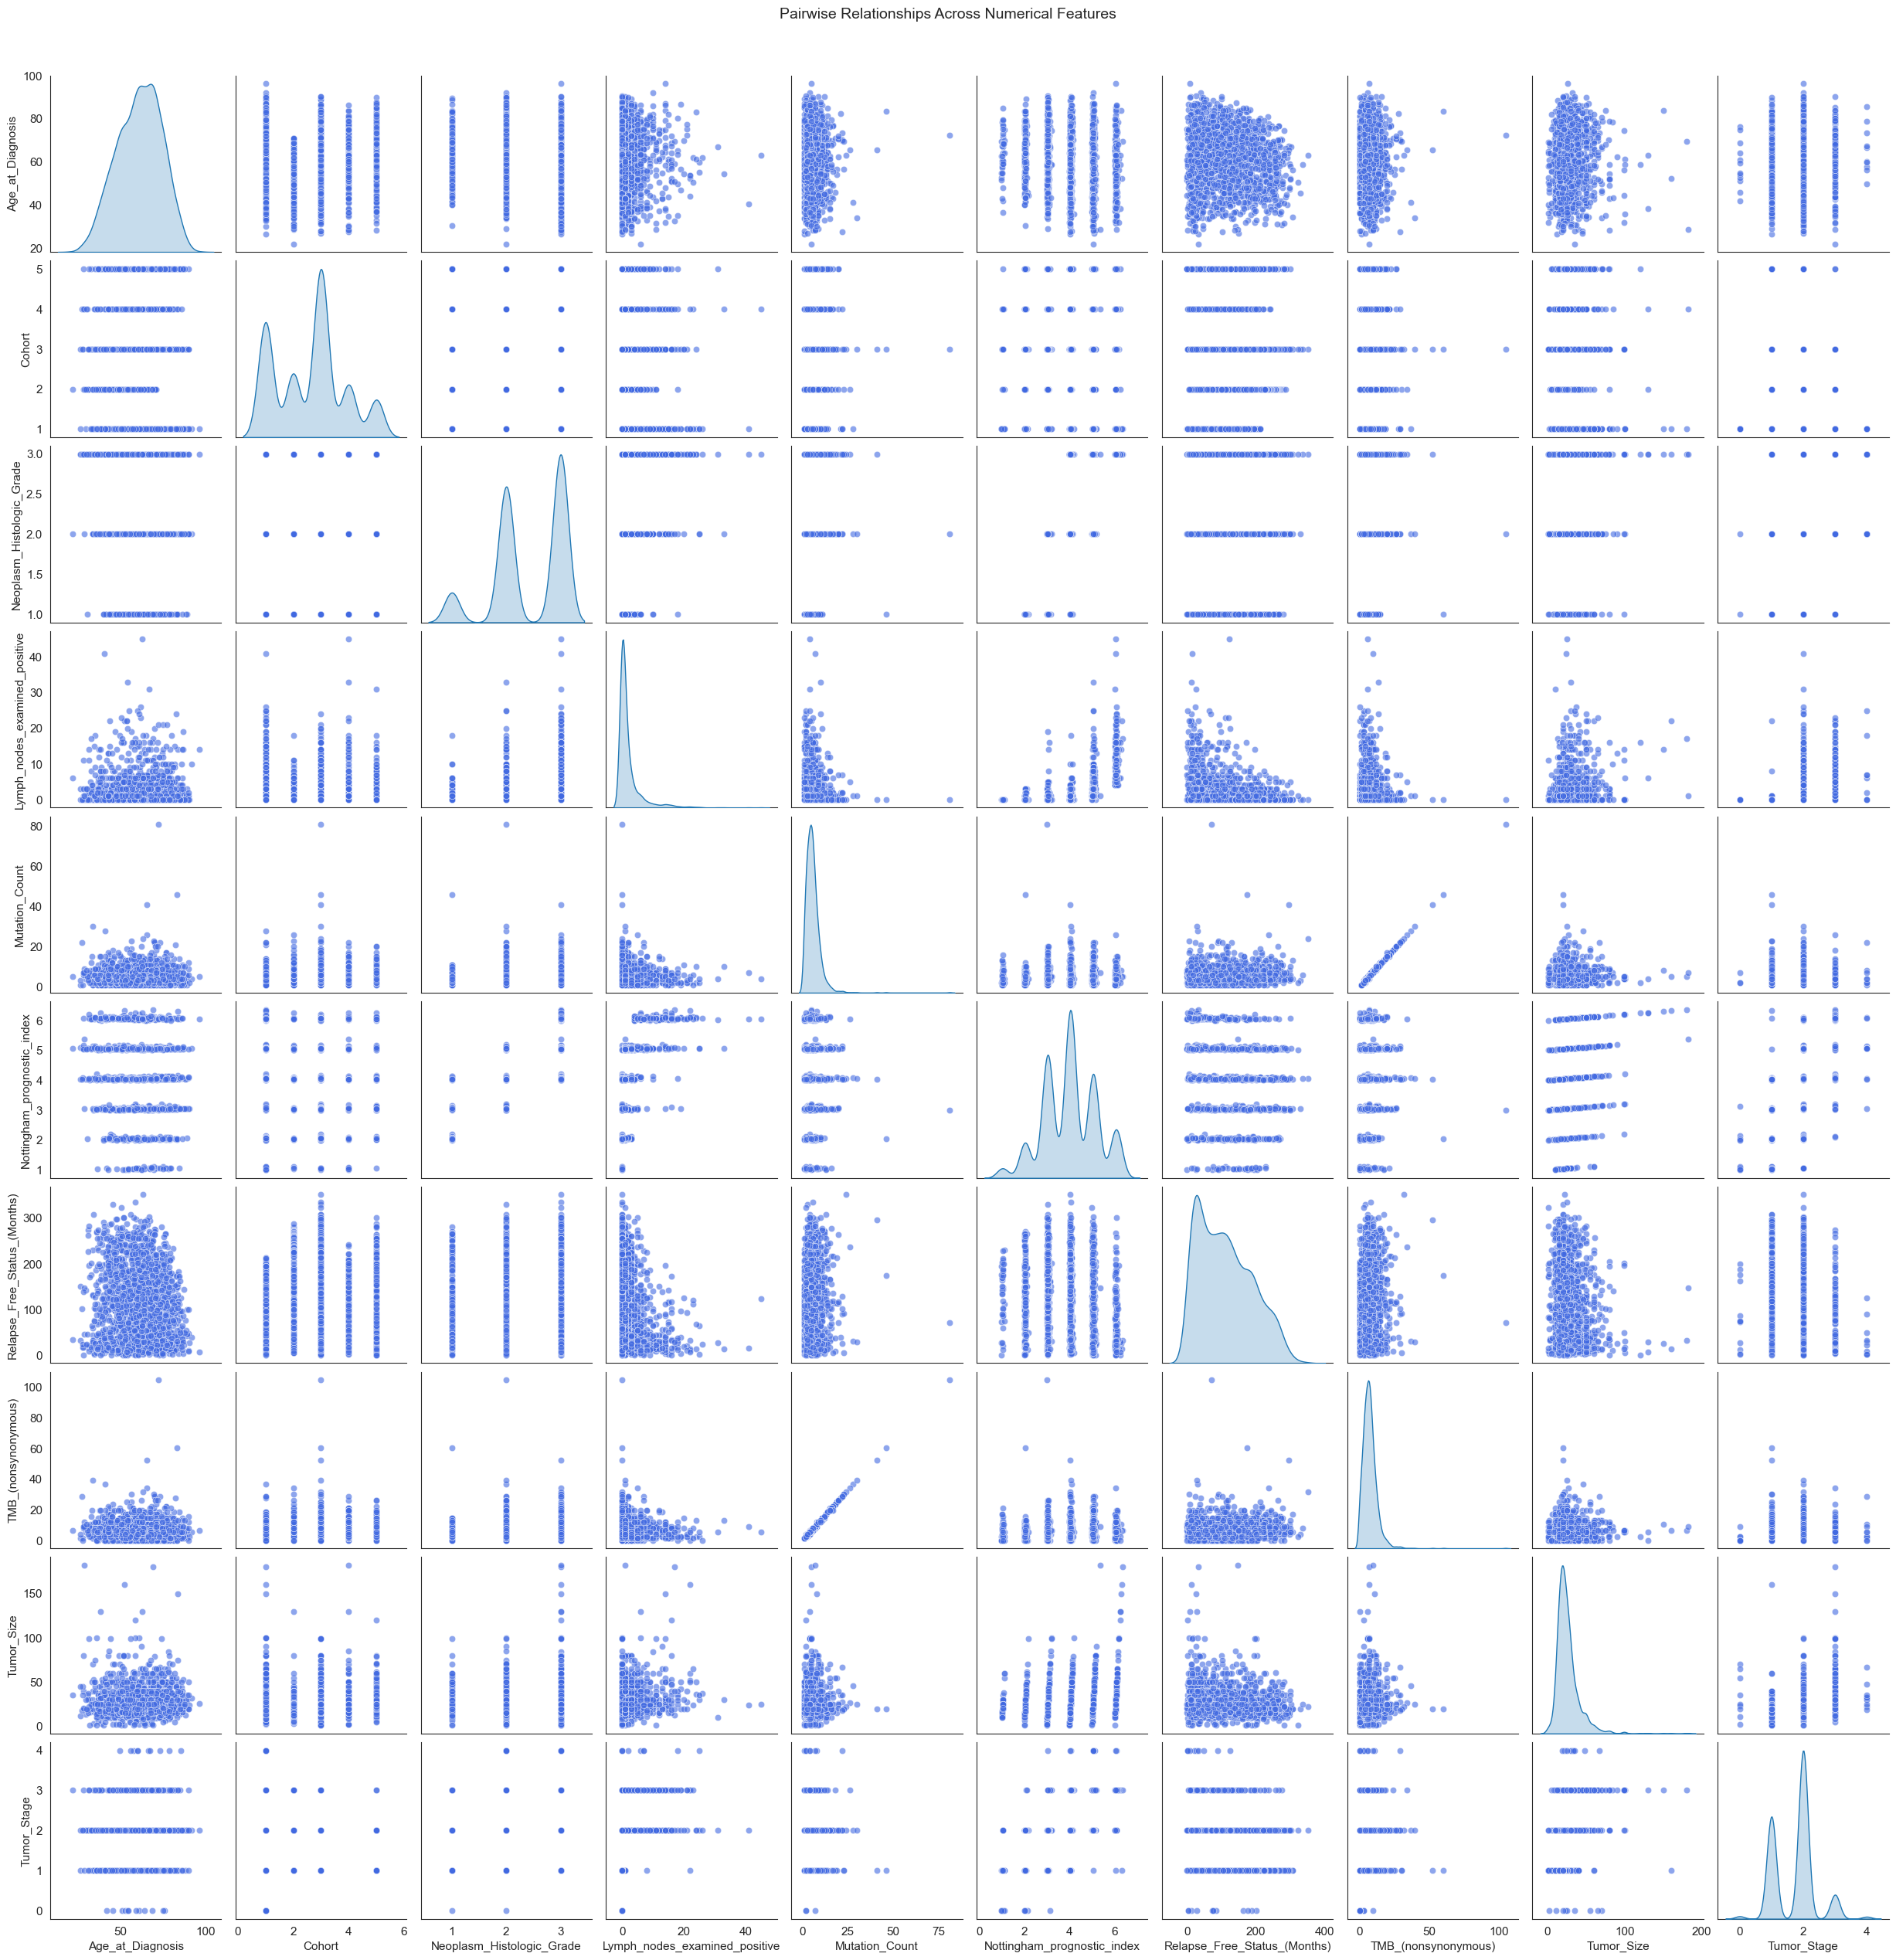

In [145]:
#numerical_cols = ['Age_at_Diagnosis', 'Tumor_Size', 'Lymph_nodes_examined_positive', 'Mutation_Count']
num_features = df_clean.select_dtypes(include=['float64']).columns
# Generate the Pairplot matrix
pp = sns.pairplot(
    data=df_clean[num_features], 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'color': 'royalblue'} # Makes overlapping dots slightly transparent
)

# Add an overall title above the grid layout
pp.figure.suptitle("Pairwise Relationships Across Numerical Features", y=1.02, fontsize=14)
pp.savefig("numerical_features_pairplot.png", dpi=300)

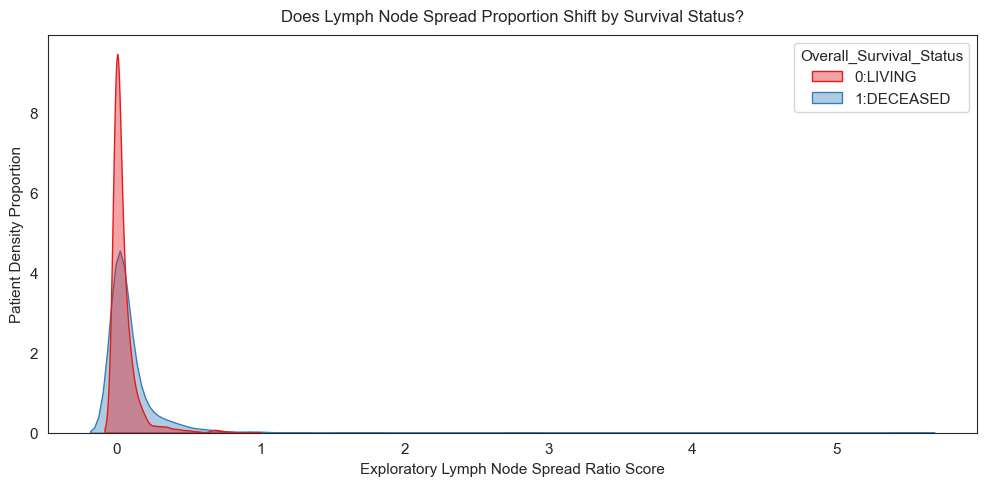

In [153]:
# Survival Separator Curve
df['Tmp_Lymph_Node_Spread_Ratio'] = df['Lymph_nodes_examined_positive'] / (df['Tumor_Size'] + 1)

plt.rcParams['figure.figsize'] = (10, 5)

# Visualizing the ratio how it naturally separates the live vs deceased patients
sns.kdeplot(
    data=df, 
    x='Tmp_Lymph_Node_Spread_Ratio', 
    hue='Overall_Survival_Status', 
    fill=True, 
    common_norm=False, 
    palette='Set1', 
    alpha=0.4
)

plt.title("Does Lymph Node Spread Proportion Shift by Survival Status?", fontsize=12, pad=10)
plt.xlabel("Exploratory Lymph Node Spread Ratio Score")
plt.ylabel("Patient Density Proportion")
plt.tight_layout()
plt.show()

# Clean up the temporary column so it doesn't mess up downstream train/test splits
df.drop(columns=['Tmp_Lymph_Node_Spread_Ratio'], inplace=True)

# Step 2: Train test split and imputation

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [103]:
df_clean = pd.read_csv('Clean_Metadata_BRCA.csv')
# Making X and y fro train test split
X = df_clean.drop(columns = ['Overall_Survival_Status'])
y = df_clean['Overall_Survival_Status']
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123, stratify = y) 

In [154]:
# Calculate standard clinical thresholds to check data distribution balance post-split
small_tumors = (X_train['Tumor_Size'] < 20).sum()
large_tumors = (X_train['Tumor_Size'] >= 20).sum()

print(f"Clinical Threshold Audit:\n- Early Stage Tumors (<20mm): {small_tumors} patients\n- Advanced Stage Tumors (>=20mm): {large_tumors} patients")

Clinical Threshold Audit:
- Early Stage Tumors (<20mm): 500 patients
- Advanced Stage Tumors (>=20mm): 1084 patients


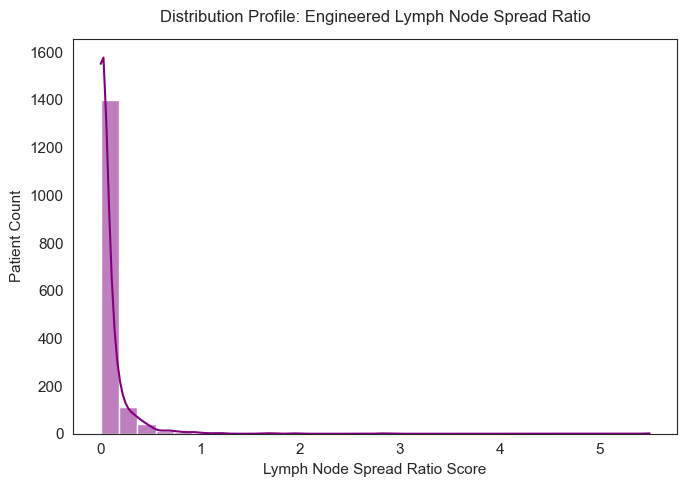

In [ ]:
X_train = X_train.copy()
X_test = X_test.copy()
# Feature Engineering: Domain-Driven ratios this will be applied independently per split
for dataset in [X_train, X_test]: # Constructing a clinical ratio to evaluate disease intensity relative to overall tumor mass
    dataset['Lymph_Node_Spread_Ratio'] = dataset['Lymph_nodes_examined_positive']/ (dataset['Tumor_Size']+1) # This +1 is for feasible division

plt.rcParams['figure.figsize'] = (7, 5)

# Plot the distribution of the newly engineered ratio
sns.histplot(X_train['Lymph_Node_Spread_Ratio'], kde=True, color='purple', bins=30)

plt.title("Distribution Profile: Engineered Lymph Node Spread Ratio", fontsize=12, pad=12)
plt.xlabel("Lymph Node Spread Ratio Score")
plt.ylabel("Patient Count")
plt.tight_layout()

plt.savefig("engineered_feature_distribution.png", dpi=300)
plt.show()

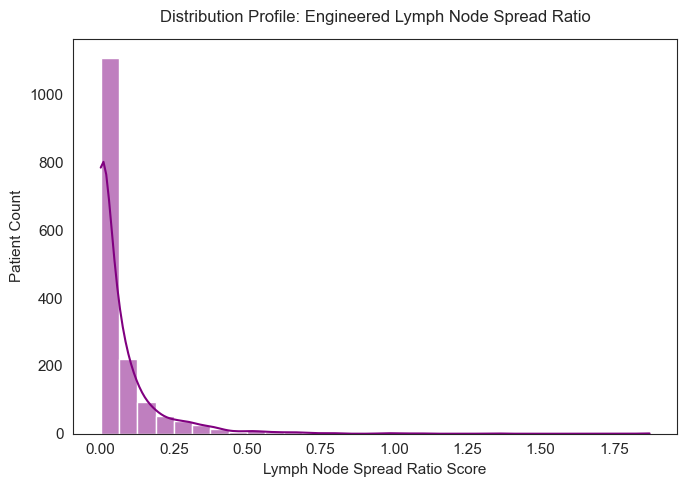

In [159]:
# Feature Engineering: Domain-Driven LOG ratios this will be applied independently per split
X_train = X_train.copy()
X_test = X_test.copy()

for dataset in [X_train, X_test]:
    # Compute original clinical ratio
    dataset['Lymph_Node_Spread_Ratio'] = dataset['Lymph_nodes_examined_positive'] / (dataset['Tumor_Size'] + 1)
    
    # Add log-stabilized variant to allow model selection of optimal numerical scale
    dataset['Log_Lymph_Node_Spread_Ratio'] = np.log1p(dataset['Lymph_Node_Spread_Ratio'])

plt.rcParams['figure.figsize'] = (7, 5)

# Plot the distribution of the newly engineered ratio
sns.histplot(X_train['Log_Lymph_Node_Spread_Ratio'], kde=True, color='purple', bins=30)

plt.title("Distribution Profile: Engineered Lymph Node Spread Ratio", fontsize=12, pad=12)
plt.xlabel("Lymph Node Spread Ratio Score")
plt.ylabel("Patient Count")
plt.tight_layout()

plt.savefig("engineered_feature_distribution.png", dpi=300)
plt.show()

In [ ]:
# Identify columns type of data
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_test.select_dtypes(exclude=['object']).columns.tolist()

#print(f"One-hot encoding {len(categorical_cols)} categorical columns...")

# Setup the ColumnTransformer
# 'encoder': applies OneHotEncoder to categorical columns and 'remainder='passthrough'
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Transforming into array
X_train_encoded_arr = preprocessor.fit_transform(X_train)
X_test_encoded_arr = preprocessor.transform(X_test)

# Extract encoded names and rebuild DataFrame cleanly
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = encoded_cat_names + numerical_cols
X_train_encoded = pd.DataFrame(X_train_encoded_arr, columns = all_feature_names)
X_test_encoded = pd.DataFrame(X_test_encoded_arr, columns = all_feature_names)

# Handling Missing Values via KNN Imputation
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_encoded), columns=X_test_encoded.columns)


# Save all the data into csv
X_train_imputed.to_csv("X_train_processed.csv", index=False)
X_test_imputed.to_csv("X_test_processed.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Pipeline splitting, encoding, and missing value processing completed successfully.")


/var/folders/nw/2dm_8qhd5rj3vc08k7bw9ss80000gn/T/ipykernel_29728/1736670698.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


Pipeline splitting, encoding, and missing value processing completed successfully.


# Step 3 Feature Correlation Matrix

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

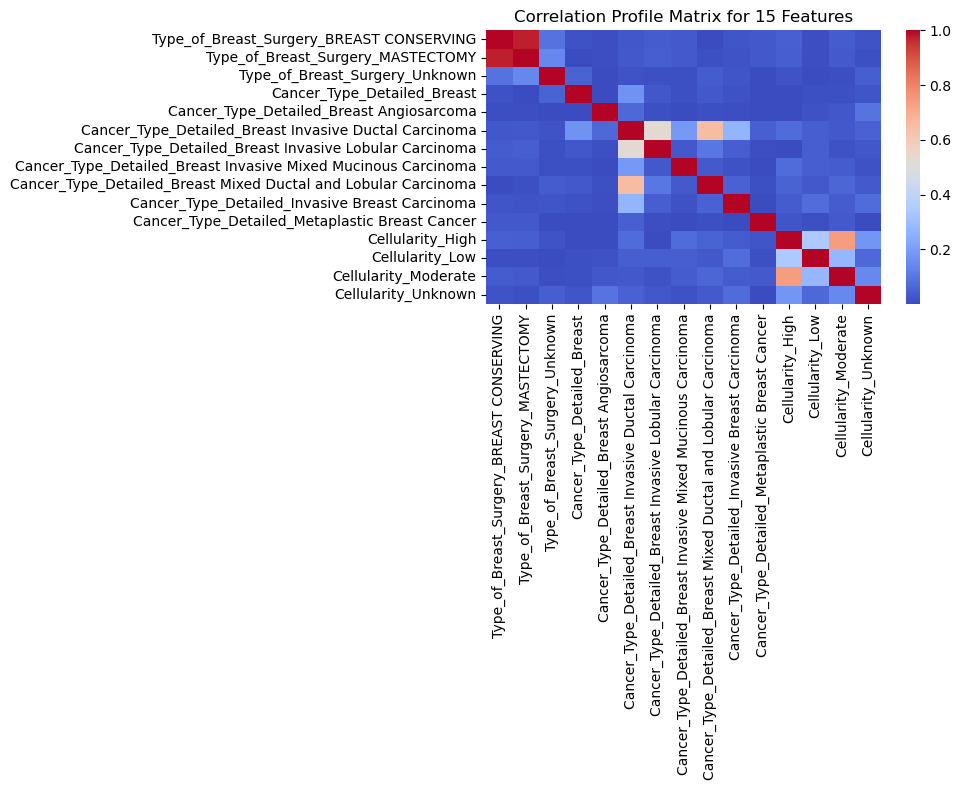


Features flagged and removed due to high collinear redundancy: ['Type_of_Breast_Surgery_MASTECTOMY', 'Chemotherapy_YES', 'Pam50_Claudin_low_subtype_Unknown', 'ER_status_measured_by_IHC_Positve', 'ER_Status_Positive', 'HER2_status_measured_by_SNP6_NEUTRAL', 'HER2_status_measured_by_SNP6_Unknown', 'HER2_Status_Positive', 'HER2_Status_Unknown', 'Tumor_Other_Histologic_Subtype_Ductal/NST', 'Tumor_Other_Histologic_Subtype_Lobular', 'Tumor_Other_Histologic_Subtype_Metaplastic', 'Tumor_Other_Histologic_Subtype_Mixed', 'Tumor_Other_Histologic_Subtype_Mucinous', 'Tumor_Other_Histologic_Subtype_Other', 'Tumor_Other_Histologic_Subtype_Unknown', 'Hormone_Therapy_Unknown', 'Hormone_Therapy_YES', 'Inferred_Menopausal_State_Pre', 'Inferred_Menopausal_State_Unknown', 'Integrative_Cluster_5', 'Integrative_Cluster_Unknown', 'Primary_Tumor_Laterality_Right', 'Oncotree_Code_BRCA', 'Oncotree_Code_BREAST', 'Oncotree_Code_IDC', 'Oncotree_Code_ILC', 'Oncotree_Code_IMMC', 'Oncotree_Code_MBC', 'Oncotree_Code_M

In [107]:
X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")

# Compute Absolute Correlation Matrix
corr_matrix = X_train.corr().abs()

# Correlation Heatmap for visibility (for 15 features)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.iloc[:15, :15], annot=False, cmap="coolwarm", cbar=True)
plt.title("Correlation Profile Matrix for 15 Features")
plt.tight_layout()
plt.show()

# Identify and Isolate Multi-Collinear Feature Pairs (> 80% Threshold)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(f"\nFeatures flagged and removed due to high collinear redundancy: {to_drop}")

# Prune Redundant Columns
X_train_pruned = X_train.drop(columns=to_drop)
X_test_pruned = X_test.drop(columns=to_drop)

# Save pruned structures
X_train_pruned.to_csv("X_train_pruned.csv", index=False)
X_test_pruned.to_csv("X_test_pruned.csv", index=False)
print(f"Remaining feature count after correlation pruning: {X_train_pruned.shape[1]}")

# Step 4: Feature selection using Random Forest

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [ ]:
X_train = pd.read_csv("X_train_pruned.csv")
X_test = pd.read_csv("X_test_pruned.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()

# Random Forest classifier
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Compile sorted feature importances
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
#threshold = 0.01
#selected_features = importances[importances['Importance'] >= threshold]['Feature'].tolist()

print(importances)

                                           Feature  Importance
48              Relapse_Free_Status_0:Not Recurred    0.141423
60                    Relapse_Free_Status_(Months)    0.140430
54                                Age_at_Diagnosis    0.129097
59                     Nottingham_prognostic_index    0.055487
61                                      Tumor_Size    0.051954
..                                             ...         ...
9   Cancer_Type_Detailed_Metaplastic Breast Cancer    0.000281
15                            Chemotherapy_Unknown    0.000267
20                    Pam50_Claudin_low_subtype_NC    0.000257
49                     Relapse_Free_Status_Unknown    0.000116
3         Cancer_Type_Detailed_Breast Angiosarcoma    0.000035

[64 rows x 2 columns]


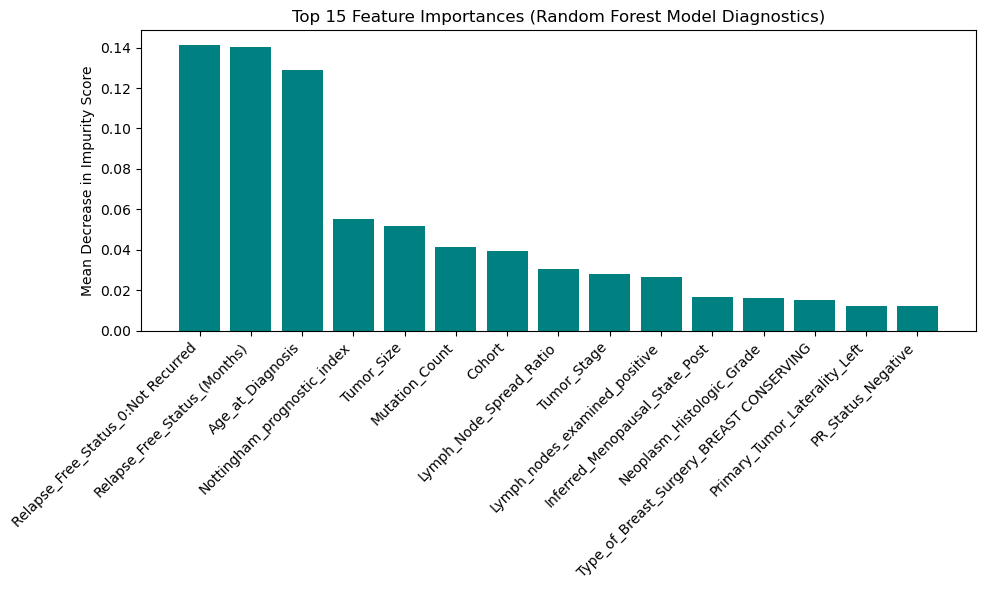

In [ ]:
# Visualizing the performance
plt.figure(figsize=(10, 6))
plt.bar(importances['Feature'].head(15), importances['Importance'].head(15), color="teal")
plt.title("Top 15 Feature Importances (Random Forest Model Diagnostics)")
plt.ylabel("Mean Decrease in Impurity Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [111]:
!pip install kneed

In [112]:
from kneed import KneeLocator

kl = KneeLocator(range(1, len(importances.Importance) + 1), importances.Importance,
                 curve='convex', direction='decreasing')
print(f"Elbow at: {kl.elbow}")

Elbow at: 11


In [113]:
# Extract final clean dataset for Machine Learning
selected_features = importances.Feature.tolist()[:11]
ML_READY_TRAIN = X_train[selected_features]
ML_READY_TRAIN['label'] = list(y_train)

ML_READY_TEST = X_test[selected_features]
ML_READY_TEST['label'] = list(y_test)

# Save
ML_READY_TRAIN.to_csv("METABRIC_ML_READY_TRAIN.csv", index=False)
ML_READY_TEST.to_csv("METABRIC_ML_READY_TEST.csv", index=False)

print(f"Final Consolidated Train Set Shape: {ML_READY_TRAIN.shape}")
print(f"Final Consolidated Test Set Shape:  {ML_READY_TEST.shape}")

Final Consolidated Train Set Shape: (1584, 12)
Final Consolidated Test Set Shape:  (397, 12)


/var/folders/nw/2dm_8qhd5rj3vc08k7bw9ss80000gn/T/ipykernel_29728/668820293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


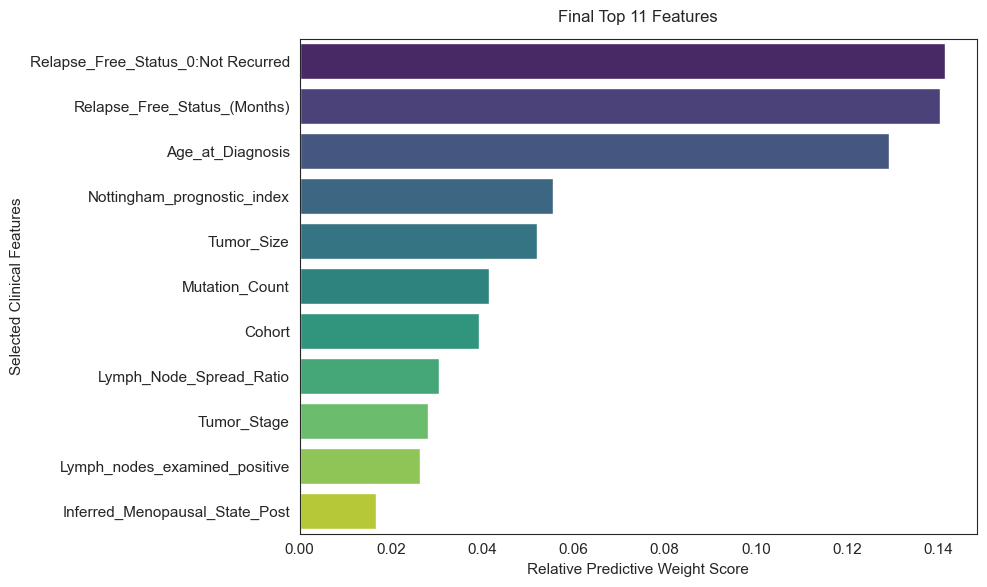

In [157]:
##################################

# Isolate the top 11 features from your existing importance tracker dataframe
top_features = importances.head(11)

plt.rcParams['figure.figsize'] = (10, 6)
sns.barplot(
    data=top_features, 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title("Final Top 11 Features", fontsize=12, pad=12)
plt.xlabel("Relative Predictive Weight Score")
plt.ylabel("Selected Clinical Features")
plt.tight_layout()
plt.show()

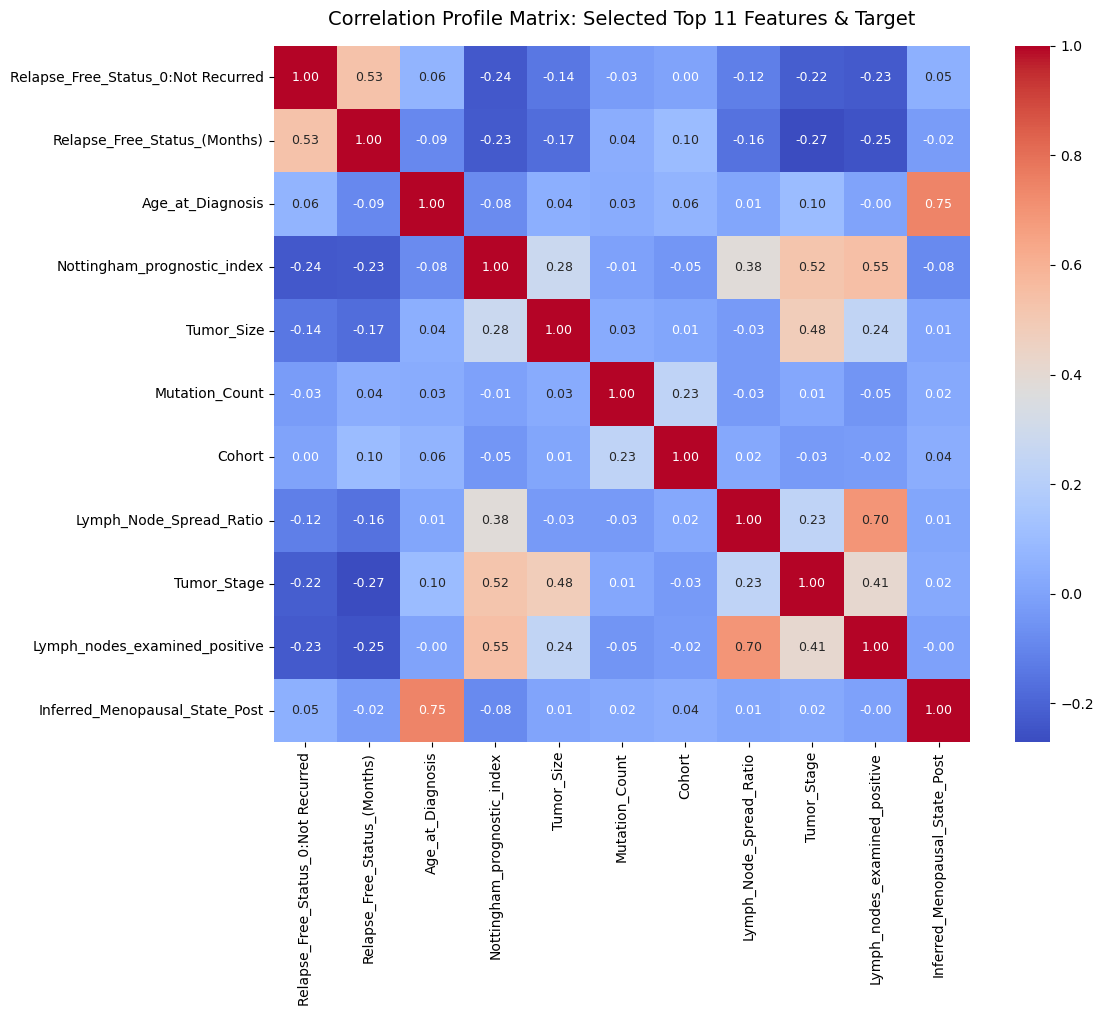

In [122]:
df_train = pd.read_csv("METABRIC_ML_READY_TRAIN.csv")

plt.rcParams['figure.figsize'] = (12, 10)
corr_matrix = df_train.corr(numeric_only=True) # this use only numerical coloumns

# heatmap with values rounded to 2 decimal places
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,annot_kws={"size": 9}) # Readable font size inside the matrix boxes


plt.title("Correlation Profile Matrix: Selected Top 11 Features & Target", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Save the final high-resolution figure
#plt.savefig("selected_features_correlation.png", dpi=300)